[2026-07-11 23:57:03] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-11 23:57:05] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-11 23:57:07] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-07-11 23:57:08] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-07-11 23:57:08] [info     ] ========== 数据检查 ==========
[2026-07-11 23:57:08] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg_ttm', 'roa_avg_ttm', 'gross_profit_rate_ttm', 'net_profit_rate_ttm', 'debt_to_asset_lf', 'current_ratio_lf', 'netflow_amount_main', 'netflow_amount_rate_main', 'net_act

时段,IC
2024-01-15~2024-02-08,0.0209
2024-09-24~2024-10-08,0.0670

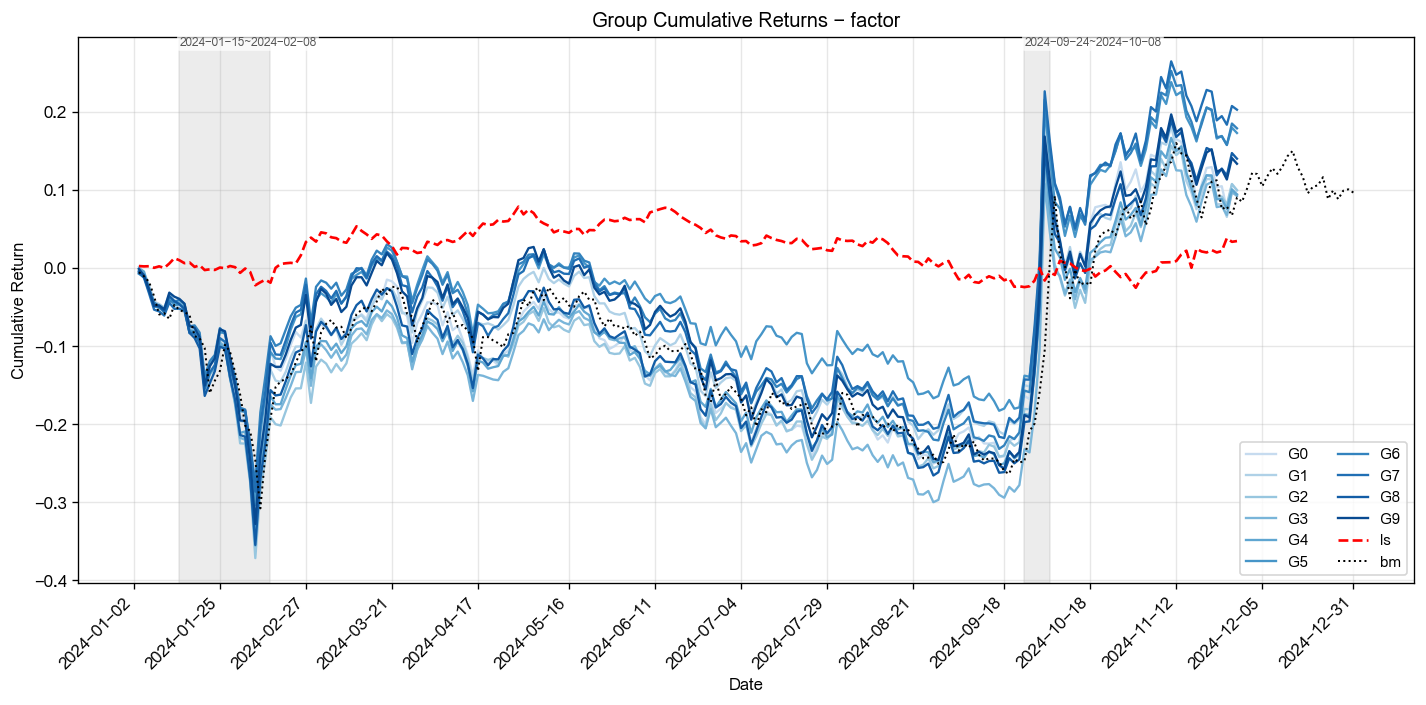
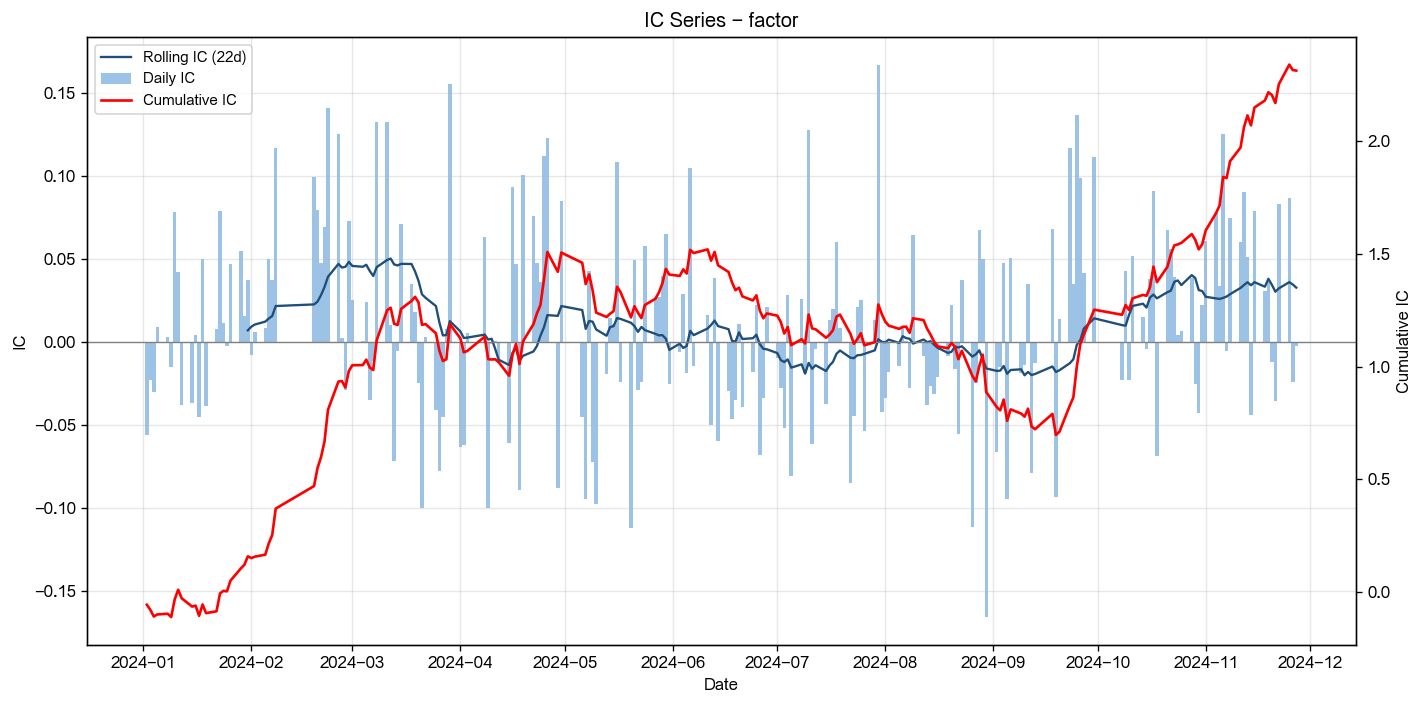
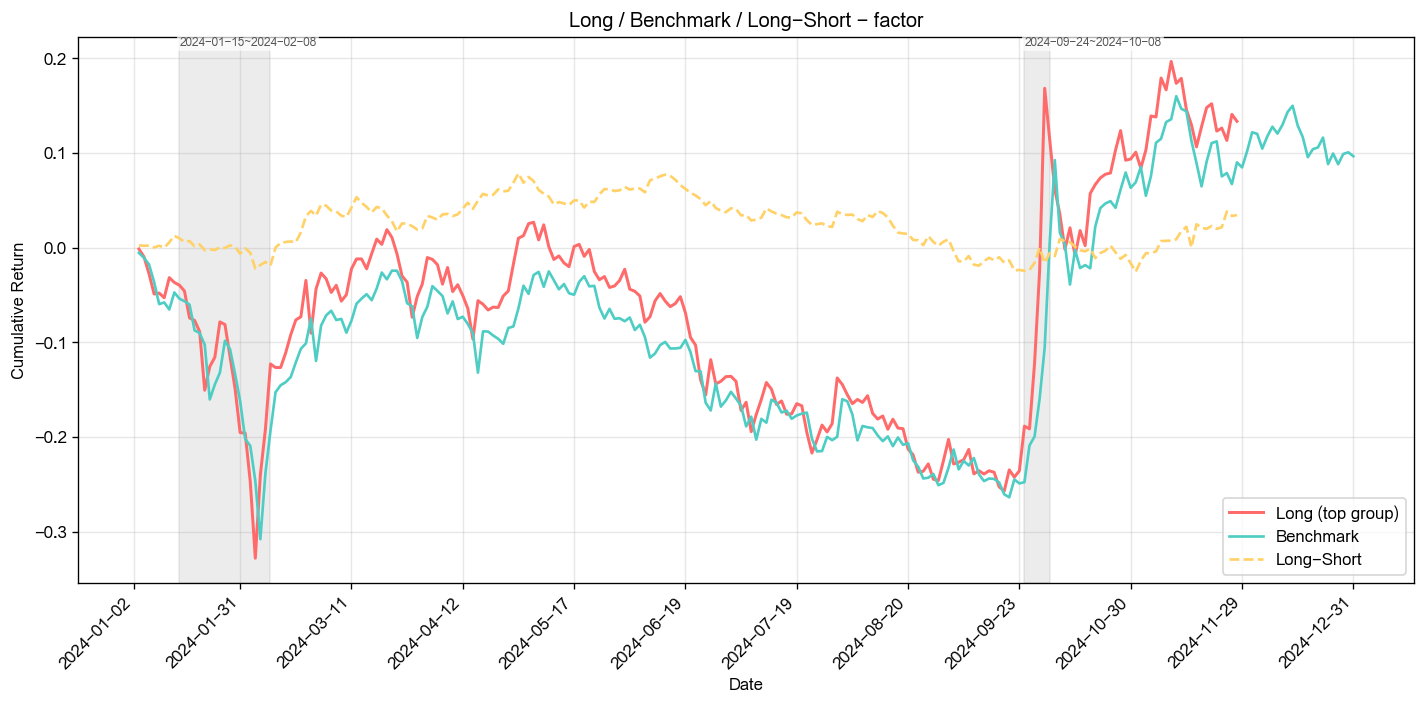
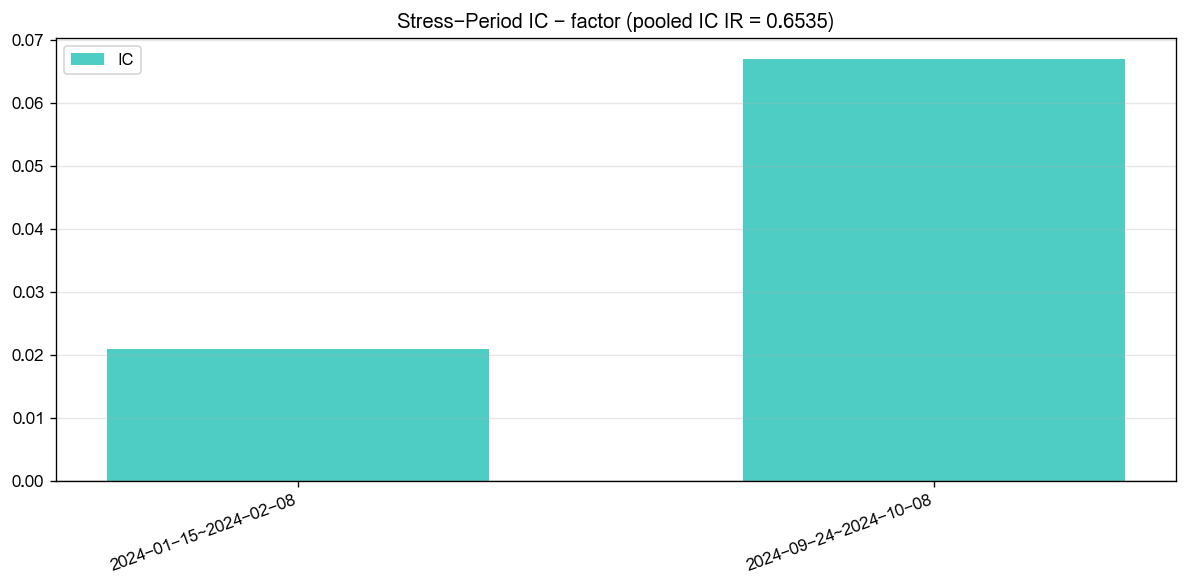
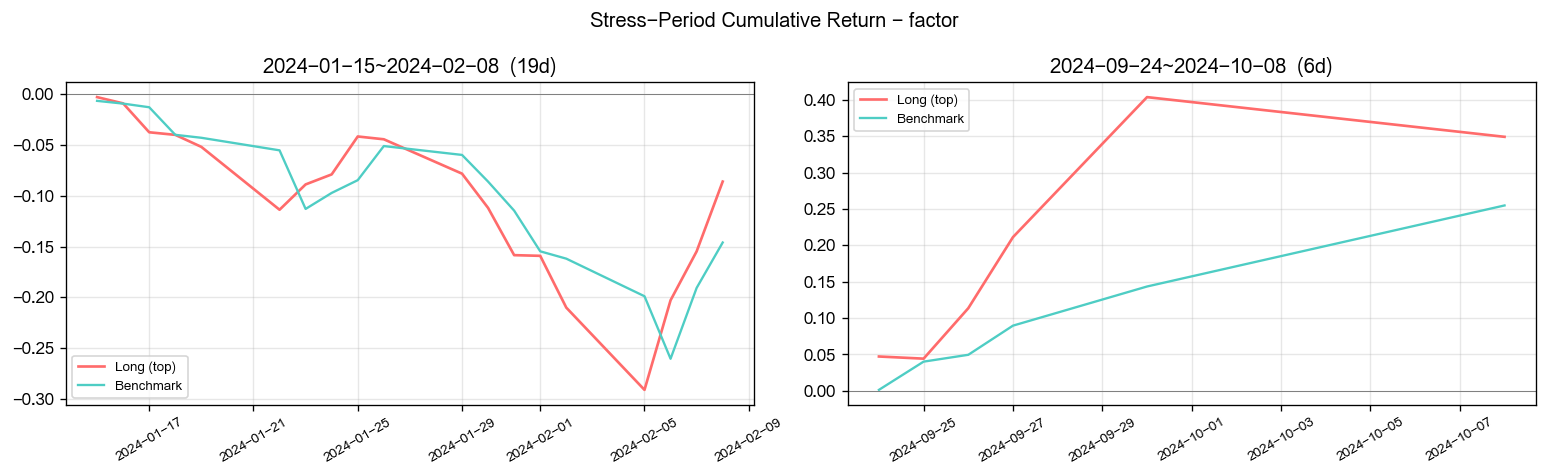

[2026-07-11 23:59:15] [info     ] ========== 因子池回归 ==========
[2026-07-11 23:59:16] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-11 23:59:17] [info     ] 获取收益率数据, 耗时: 2.0987 秒
[2026-07-11 23:59:20] [info     ] 滚动 Elastic Net 拟合, 耗时: 2.1754 秒
[2026-07-11 23:59:20] [info     ] 统计 回归结果, 耗时: 0.1008 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,factor,2.2164,0.0067,0.0030,1.0000
2,rsi_12,1.8850,0.0444,0.0235,1.0000
3,amount,1.6910,0.0182,0.0108,0.9000
4,netflow_amount_rate_main,1.5735,0.0099,0.0063,1.0000
5,netflow_amount_main,1.5138,0.0252,0.0166,1.0000
6,gross_profit_rate_ttm,1.5034,0.0069,0.0046,1.0000
7,net_profit_rate_ttm,1.4405,0.0040,0.0028,0.8000
8,bias_20,1.4266,0.0301,0.0211,0.9000
9,pb,1.4195,0.0097,0.0069,1.0000
10,cci_14,1.3996,0.0335,0.0240,1.0000

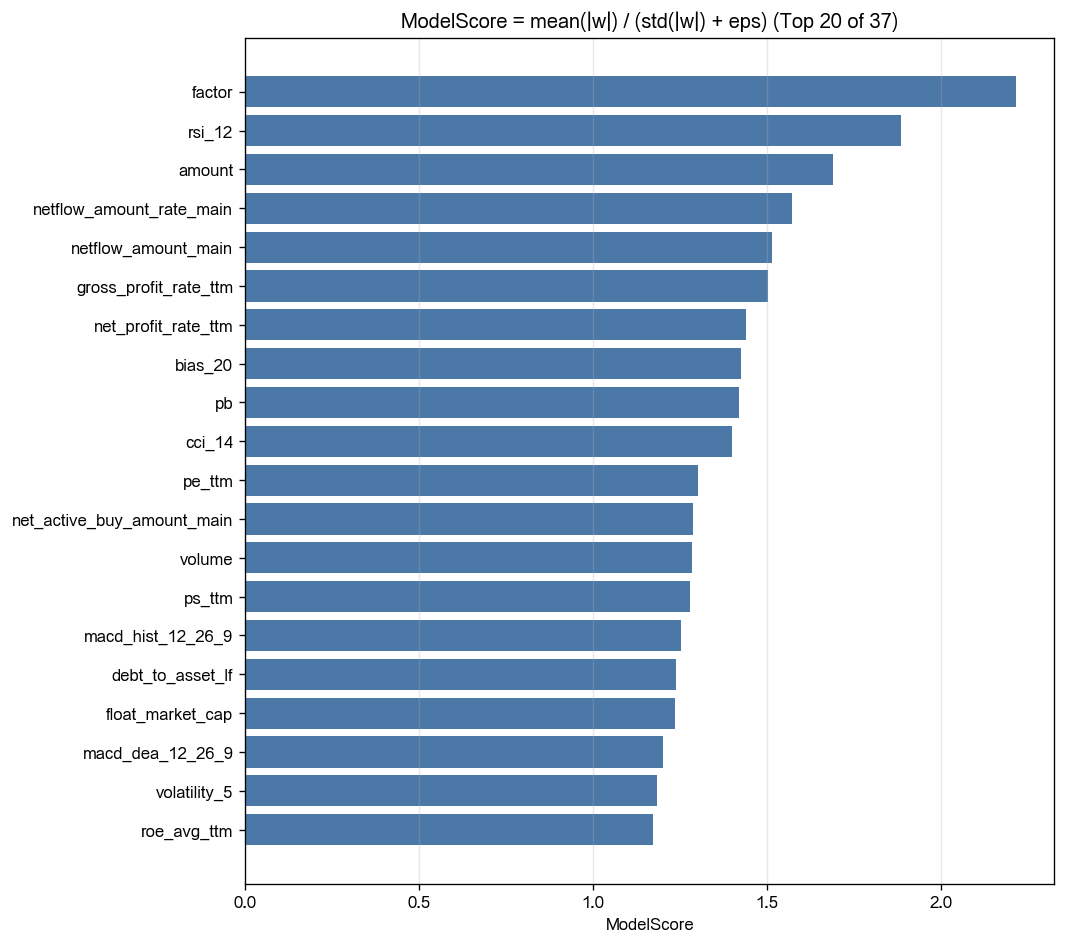
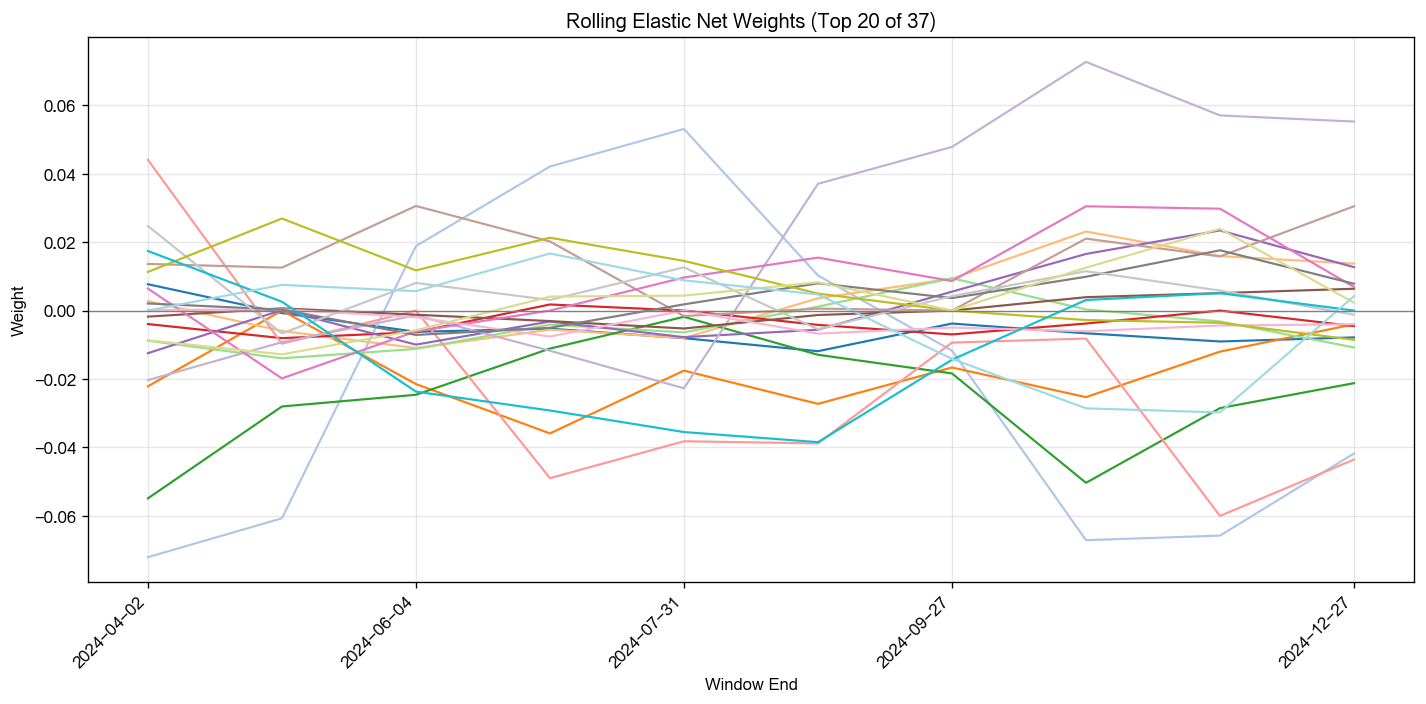
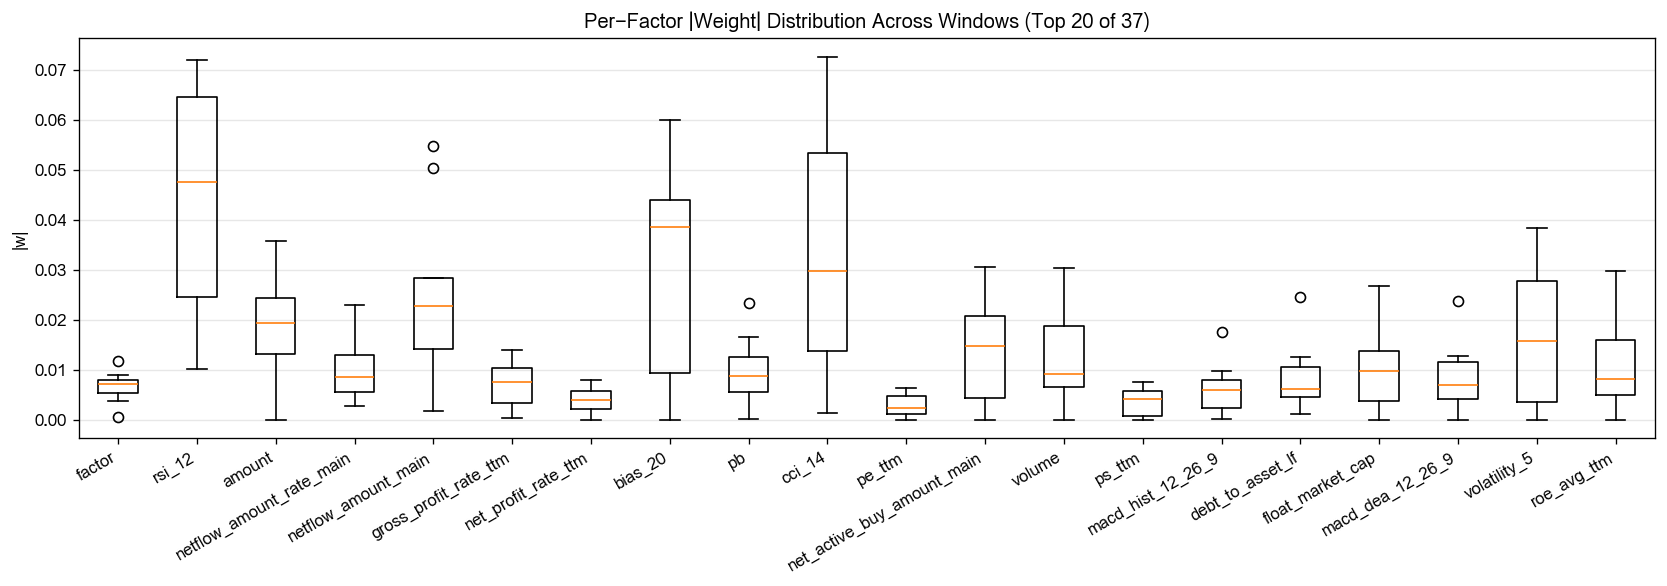
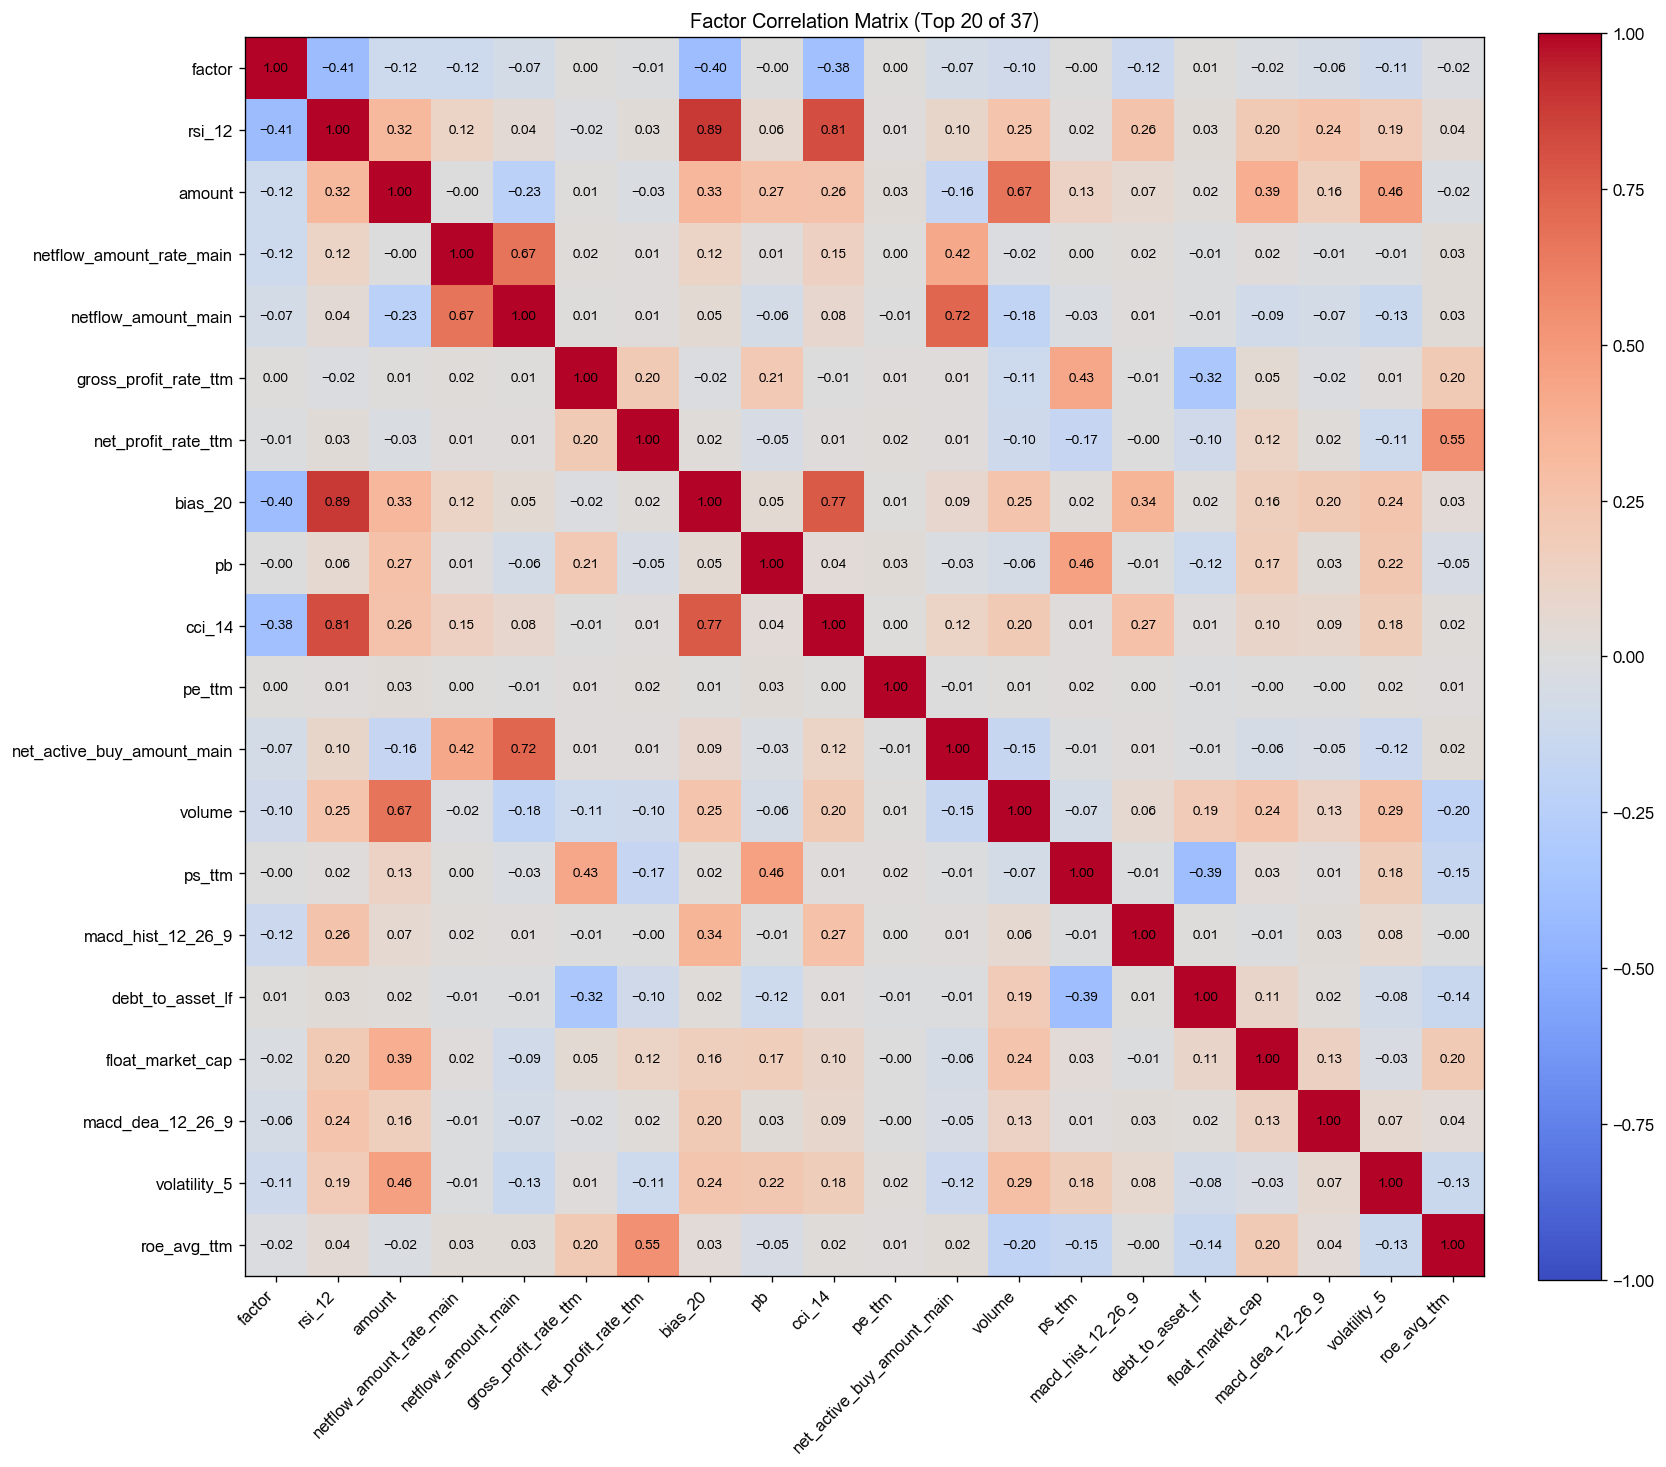

[2026-07-11 23:59:22] [warning  ] 返回的Outputs实例(size=34862289) 大于 64K, 将不会被缓存
[2026-07-11 23:59:22] [info     ] bigalpha_eval.v4 运行完成 [136.361s].
factor_generation_seconds=57.07
evaluate_seconds=138.98
        date instrument    factor
0 2024-01-02  000006.SZ  1.109354
1 2024-01-02  000012.SZ -0.184930
2 2024-01-02  000016.SZ -1.452084
3 2024-01-02  000019.SZ -1.160608
4 2024-01-02  000025.SZ  0.000000
{'raw_factor':              date instrument    factor
0      2024-01-02  000006.SZ  1.109354
1      2024-01-02  000012.SZ -0.184930
2      2024-01-02  000016.SZ -1.452084
3      2024-01-02  000019.SZ -1.160608
4      2024-01-02  000025.SZ  0.000000
...           ...        ...       ...
241995 2024-12-31  688766.SH  0.021479
241996 2024-12-31  688776.SH  1.728120
241997 2024-12-31  688779.SH  0.036305
241998 2024-12-31  688789.SH -0.887973
241999 2024-12-31  688798.SH  0.718976

[242000 rows x 3 columns], 'process_factor':              date instrument    factor
0      2024-01-02  000006.S

In [15]:
import warnings
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")


@dataclass
class PairsConfig:
    lookback_days: int = 100
    corr_lookback: int = 60
    spread_window: int = 20
    rebalance_freq: int = 30
    top_k: int = 3
    corr_threshold: float = 0.70
    min_corr_obs: int = 40
    min_peer_count: int = 2
    min_spread_obs: int = 12
    winsor_quantile: float = 0.01


DEFAULT_CONFIG = PairsConfig()


def load_stock_pool(start_date: str, end_date: str) -> pd.DataFrame:
    import dai

    stock_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={"date": [start_date, end_date]},
    ).df()
    stock_pool["date"] = pd.to_datetime(stock_pool["date"])
    stock_pool = (
        stock_pool.drop_duplicates(["date", "instrument"])
        .sort_values(["date", "instrument"])
        .reset_index(drop=True)
    )
    return stock_pool


def load_daily_close_panel(
    datasources: Dict[str, str],
    start_date: str,
    end_date: str,
    lookback_days: int,
) -> pd.DataFrame:
    """参考官方模板的 SQL 调用风格，将分钟收盘价聚合为日频收盘价。"""
    import dai

    bar1m_table = datasources["bar1m"]
    query_start_date = pd.to_datetime(start_date) - pd.Timedelta(days=lookback_days)

    sql = f"""
    WITH cte_day_bar AS (
        SELECT
            CAST(date_trunc('day', date) AS DATETIME) AS date,
            instrument,
            date AS minute_dt,
            close
        FROM {bar1m_table}
    ),
    cte_daily_close AS (
        SELECT
            date,
            instrument,
            last(close ORDER BY minute_dt) AS close
        FROM cte_day_bar
        GROUP BY date, instrument
    )
    SELECT date, instrument, close
    FROM cte_daily_close
    PRUNE JOIN bigalpha_2026_instruments USING (date, instrument)
    """
    daily_close = dai.query(sql, filters={"date": [query_start_date, end_date]}).df()
    daily_close["date"] = pd.to_datetime(daily_close["date"])
    daily_close = (
        daily_close.drop_duplicates(["date", "instrument"])
        .sort_values(["instrument", "date"])
        .reset_index(drop=True)
    )
    return daily_close


def build_daily_panel(daily_close: pd.DataFrame) -> pd.DataFrame:
    panel = daily_close.copy()
    panel["ret_1d"] = panel.groupby("instrument")["close"].pct_change()
    panel["log_close"] = np.log(panel["close"].replace(0, np.nan))
    return panel


def build_pair_map(
    return_window: pd.DataFrame,
    top_k: int,
    corr_threshold: float,
    min_corr_obs: int,
) -> Tuple[Dict[str, List[str]], Dict[str, float]]:
    corr = return_window.corr(min_periods=min_corr_obs)
    pair_map: Dict[str, List[str]] = {}
    corr_score_map: Dict[str, float] = {}

    for instrument in corr.columns:
        corr_series = corr[instrument].drop(labels=[instrument], errors="ignore").dropna()
        corr_series = corr_series[corr_series >= corr_threshold].sort_values(ascending=False)
        selected = corr_series.head(top_k)
        pair_map[instrument] = selected.index.tolist()
        corr_score_map[instrument] = float(selected.mean()) if not selected.empty else np.nan

    return pair_map, corr_score_map


def summarize_pairs(
    rebalance_date: pd.Timestamp,
    pair_map: Dict[str, List[str]],
    corr_score_map: Dict[str, float],
) -> pd.DataFrame:
    rows = []
    for instrument, peers in pair_map.items():
        rows.append(
            {
                "date": rebalance_date,
                "instrument": instrument,
                "peer_count": len(peers),
                "avg_corr": corr_score_map.get(instrument),
                "peers": ",".join(peers),
            }
        )
    return pd.DataFrame(rows)


def cross_sectional_zscore(x: pd.Series, winsor_quantile: float) -> pd.Series:
    x = x.replace([np.inf, -np.inf], np.nan)
    if x.notna().sum() < 20:
        return pd.Series(np.nan, index=x.index)
    lower = x.quantile(winsor_quantile)
    upper = x.quantile(1 - winsor_quantile)
    x = x.clip(lower, upper)
    std = x.std()
    if pd.isna(std) or std < 1e-12:
        return pd.Series(np.nan, index=x.index)
    return (x - x.mean()) / std


def generate_pairs_factor(
    panel: pd.DataFrame,
    start_date: str,
    end_date: str,
    config: PairsConfig = DEFAULT_CONFIG,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    close_wide = (
        panel.pivot(index="date", columns="instrument", values="close")
        .sort_index()
        .astype(float)
    )
    ret_wide = close_wide.pct_change()
    log_close = np.log(close_wide.replace(0, np.nan))
    trade_dates = close_wide.index.to_list()

    factor_frames: List[pd.DataFrame] = []
    pair_frames: List[pd.DataFrame] = []
    rebalance_index = list(range(config.corr_lookback, len(trade_dates), config.rebalance_freq))

    for pos, start_idx in enumerate(rebalance_index):
        end_idx = rebalance_index[pos + 1] if pos + 1 < len(rebalance_index) else len(trade_dates)
        rebalance_date = trade_dates[start_idx]
        return_window = ret_wide.iloc[start_idx - config.corr_lookback : start_idx]
        pair_map, corr_score_map = build_pair_map(
            return_window=return_window,
            top_k=config.top_k,
            corr_threshold=config.corr_threshold,
            min_corr_obs=config.min_corr_obs,
        )

        if not any(pair_map.values()):
            continue

        segment_start = max(0, start_idx - config.spread_window + 1)
        segment_close = log_close.iloc[segment_start:end_idx]
        segment_dates = close_wide.index[start_idx:end_idx]
        instrument_frames: List[pd.DataFrame] = []

        for instrument, peers in pair_map.items():
            if len(peers) < config.min_peer_count:
                continue
            valid_peers = [peer for peer in peers if peer in segment_close.columns]
            if len(valid_peers) < config.min_peer_count or instrument not in segment_close.columns:
                continue

            spread = segment_close[instrument] - segment_close[valid_peers].mean(axis=1)
            spread_mean = spread.rolling(
                window=config.spread_window,
                min_periods=config.min_spread_obs,
            ).mean()
            spread_std = spread.rolling(
                window=config.spread_window,
                min_periods=config.min_spread_obs,
            ).std()
            zscore = (spread - spread_mean) / (spread_std + 1e-8)
            quality = corr_score_map.get(instrument)
            if pd.isna(quality):
                continue

            signal = (-zscore * quality).loc[segment_dates]
            instrument_frames.append(
                pd.DataFrame(
                    {
                        "date": segment_dates,
                        "instrument": instrument,
                        "raw_factor": signal.values,
                    }
                )
            )

        if instrument_frames:
            factor_frames.append(pd.concat(instrument_frames, ignore_index=True))
            pair_frames.append(summarize_pairs(rebalance_date, pair_map, corr_score_map))

    if not factor_frames:
        empty_factor = pd.DataFrame(columns=["date", "instrument", "factor"])
        empty_pairs = pd.DataFrame(
            columns=["date", "instrument", "peer_count", "avg_corr", "peers"]
        )
        return empty_factor, empty_pairs

    factor_data = pd.concat(factor_frames, ignore_index=True)
    factor_data = factor_data.drop_duplicates(["date", "instrument"], keep="last")
    factor_data["date"] = pd.to_datetime(factor_data["date"])
    factor_data["factor"] = factor_data.groupby("date")["raw_factor"].transform(
        lambda x: cross_sectional_zscore(x, winsor_quantile=config.winsor_quantile)
    )
    factor_data = factor_data.replace([np.inf, -np.inf], np.nan)
    factor_data = factor_data.dropna(subset=["factor"])
    factor_data = factor_data[
        (factor_data["date"] >= pd.to_datetime(start_date))
        & (factor_data["date"] <= pd.to_datetime(end_date))
    ]
    factor_data = factor_data[["date", "instrument", "factor"]].sort_values(
        ["date", "instrument"]
    )

    pair_info = pd.concat(pair_frames, ignore_index=True) if pair_frames else pd.DataFrame()
    return factor_data.reset_index(drop=True), pair_info


def main(datasources, start_date, end_date):
    """
    配对交易套利因子主函数。

    评测时平台会自动替换 datasources / start_date / end_date 三个入参并调用本函数。
    返回结果严格为 ['date', 'instrument', 'factor'] 三列。
    """
    daily_close = load_daily_close_panel(
        datasources=datasources,
        start_date=start_date,
        end_date=end_date,
        lookback_days=DEFAULT_CONFIG.lookback_days,
    )
    panel = build_daily_panel(daily_close)
    factor_data, _ = generate_pairs_factor(
        panel=panel,
        start_date=start_date,
        end_date=end_date,
        config=DEFAULT_CONFIG,
    )
    stock_pool = load_stock_pool(start_date, end_date)
    factor_data = stock_pool.merge(factor_data, on=["date", "instrument"], how="left")
    factor_data["factor"] = factor_data["factor"].fillna(0.0)
    factor_data = factor_data[["date", "instrument", "factor"]].sort_values(
        ["date", "instrument"]
    )
    return factor_data.reset_index(drop=True)


def evaluate_factor(
    datasources,
    start_date,
    end_date,
    factor_data: Optional[pd.DataFrame] = None,
    show: bool = True,
):
    """直接复用官方模板评测逻辑。"""
    from bigmodule import M
    import dai

    if factor_data is None:
        factor_data = main(datasources, start_date, end_date)

    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={"date": [start_date, end_date]},
    ).df()

    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=show,
    )
    return result


if __name__ == "__main__":
    import time

    RUN_DEMO = True

    if RUN_DEMO:
        datasources = {"bar1m": "bigalpha_2026_stock_bar1m"}
        start_date = "2024-01-01 00:00:00"
        end_date = "2024-12-31 23:59:59"

        t0 = time.time()
        factor_data = main(datasources, start_date, end_date)
        t1 = time.time()
        result = evaluate_factor(
            datasources,
            start_date,
            end_date,
            factor_data=factor_data,
            show=True,
        )
        t2 = time.time()

        print(f"factor_generation_seconds={t1 - t0:.2f}")
        print(f"evaluate_seconds={t2 - t1:.2f}")
        print(factor_data.head())
        print(result)
